# 02 — Feature Engineering & Splits

Materialise the 30-dimensional `FeatureVector` defined in
[`design.md`](../../.kiro/specs/rexell-ai-bot-detection-integration/design.md#L302)
from the two CSVs, persist a stratified 70 / 15 / 15 split to parquet,
and validate that no leaky columns leak through.

Downstream notebooks (`03` – `06`) consume the parquet split rather
than re-deriving the features so every model trains on **exactly**
the same data.


## Imports


In [1]:
import sys, pathlib

sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rexell_ml import data, features

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
data.set_seed(42)


2026-04-29 16:48:47.732782: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Master CSV → wallet-level feature matrix

The master CSV is transaction-level, but the bot-detection model scores
*wallets per session*. We aggregate transactions per wallet and engineer
roughly thirty numeric features grouped into:

- **counts**: tx, purchase, resale, failure
- **ticket volume**: sum / mean / max / std of `ticket_count`
- **price + markup**: mean / std / max + high-markup ratio
- **diversity**: distinct events, distinct IPs, IP entropy, event entropy
- **temporal**: active hours / days, hour entropy, session span,
  tx/hour, min / mean inter-tx delay, burstiness
- **behavioural proxies**: purchase-to-resale ratio, max tickets per
  event, count of events with resale activity

A wallet is labelled positive if **any** of its transactions is flagged
as `scalping_label == 1`.


In [2]:
master = data.load_master()
master_feats = features.build_master_features(master)
print("wallets:", len(master_feats), " feature cols:", master_feats.shape[1] - 2)
master_feats.head()


wallets: 4282  feature cols: 30


,wallet_address,tx_count,purchase_count,resale_count,failure_count,ticket_count_sum,ticket_count_mean,ticket_count_max,ticket_count_std,price_paid_mean,price_paid_std,price_paid_max,markup_pct_mean,markup_pct_std,markup_pct_max,high_markup_ratio,unique_events,unique_ips,ip_entropy,event_entropy,active_hours,active_dows,hour_entropy,session_span_hours,tx_per_hour,min_inter_tx_seconds,mean_inter_tx_seconds,burstiness,purchase_resale_ratio,max_tickets_per_event,events_with_resale,label
0,0x4ac429ec22574039a5d1bbf8f8e3b18b,6,6,0,0,12,2.000000,4,1.095445,275.000000,139.187643,456.0,0.0,0.0,0.0,0.0,6,6,2.584963,2.584963,6,4,2.584963,1254.156110,0.004784,1.860870e+05,9.029924e+05,0.0,6.0,4,0,0
1,0xdc5c8632d1434698b31d21c1785a2d2b,4,4,0,0,13,3.250000,4,0.957427,313.250000,170.913965,466.0,0.0,0.0,0.0,0.0,4,4,2.000000,2.000000,4,3,2.000000,1307.910832,0.003058,5.923300e+05,1.569493e+06,0.0,4.0,4,0,0
2,0xfd8346ff63bf4c21a1bfc80cf5371c4d,47,0,0,17,511,10.872340,20,5.105909,253.978723,114.533931,474.0,0.0,0.0,0.0,0.0,31,47,5.554589,4.783000,22,7,4.110455,1275.515554,0.036848,6.055994e+03,9.982296e+04,0.0,0.0,50,0,1
3,0x1efe997d08934f5da015f235583378e2,4,4,0,0,12,3.000000,4,1.414214,306.750000,88.288825,363.0,0.0,0.0,0.0,0.0,4,4,2.000000,2.000000,4,2,2.000000,851.613054,0.004697,5.094299e+04,1.021936e+06,0.0,4.0,4,0,0
4,0x2961501270c44dd388b8f4e5bd092018,3,3,0,0,8,2.666667,4,1.154701,143.666667,54.307765,177.0,0.0,0.0,0.0,0.0,3,3,1.584963,1.584963,3,3,1.584963,940.049167,0.003191,1.660388e+06,1.692088e+06,0.0,3.0,4,0,0


In [3]:
# All numeric features the models will see (excluding wallet_address + label).
feature_cols = [c for c in master_feats.columns if c not in ("wallet_address", "label")]
print(f"{len(feature_cols)} features:")
for c in feature_cols:
    print(" -", c)


30 features:
 - tx_count
 - purchase_count
 - resale_count
 - failure_count
 - ticket_count_sum
 - ticket_count_mean
 - ticket_count_max
 - ticket_count_std
 - price_paid_mean
 - price_paid_std
 - price_paid_max
 - markup_pct_mean
 - markup_pct_std
 - markup_pct_max
 - high_markup_ratio
 - unique_events
 - unique_ips
 - ip_entropy
 - event_entropy
 - active_hours
 - active_dows
 - hour_entropy
 - session_span_hours
 - tx_per_hour
 - min_inter_tx_seconds
 - mean_inter_tx_seconds
 - burstiness
 - purchase_resale_ratio
 - max_tickets_per_event
 - events_with_resale


### Feature distributions on the master CSV


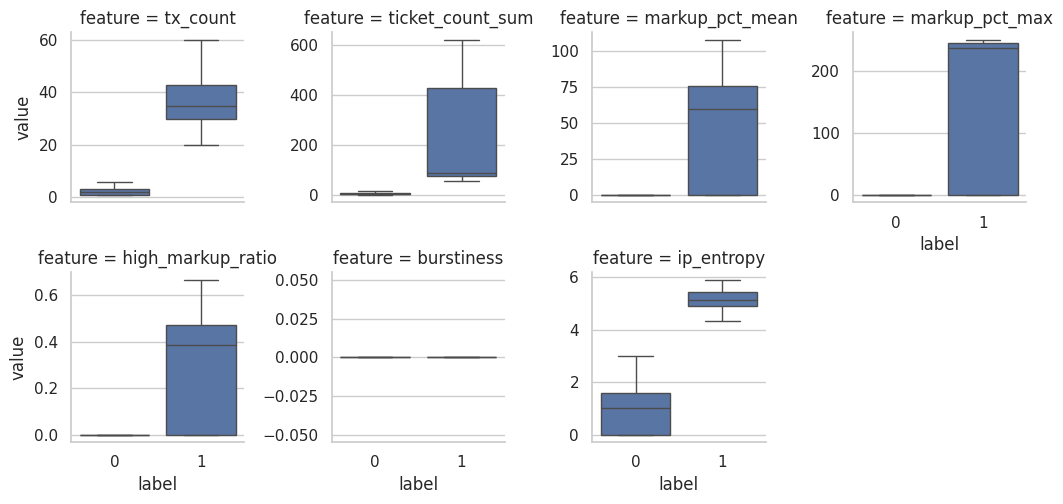

In [4]:
# Quick visual sanity check on a handful of high-signal features.
focus = [
    "tx_count", "ticket_count_sum", "markup_pct_mean", "markup_pct_max",
    "high_markup_ratio", "burstiness", "ip_entropy",
]
m = master_feats.melt(id_vars="label", value_vars=focus, var_name="feature", value_name="value")
g = sns.catplot(
    data=m, x="label", y="value", col="feature", col_wrap=4,
    kind="box", height=2.6, sharey=False, showfliers=False,
)
g.fig.tight_layout()


### Stratified 70 / 15 / 15 split, persisted to parquet


In [5]:
X = master_feats[feature_cols].copy()
y = master_feats["label"].astype(int)

split = data.stratified_split(X, y, test_size=0.15, val_size=0.15, random_state=42)
for name, shape in split.shapes().items():
    print(f"{name:>5}:  shape={shape}  pos_pct={split.__dict__['y_'+name].mean():.4f}")

out_path = data.save_split(split, name="master_features")
print("\npersisted to:", out_path)


train:  shape=(2996, 30)  pos_pct=0.0164
  val:  shape=(643, 30)  pos_pct=0.0156
 test:  shape=(643, 30)  pos_pct=0.0171

persisted to: /home/ubuntu/repos/Rexell/ml-training/data/master_features.parquet


### Min-max normalisation

Tree-based models don't need it, but the deep-learning notebooks (04, 05)
and Logistic Regression do. Fit on **train only** and reuse on val/test.


In [6]:
scaler, X_tr, X_va, X_te = features.normalize(split.X_train, split.X_val, split.X_test)
print("scaler fit on", X_tr.shape[0], "train rows")
X_tr.describe().T[["min", "max", "mean", "std"]].head(10)


scaler fit on 2996 train rows


,min,max,mean,std
tx_count,0.0,1.0,0.030623,0.083073
purchase_count,0.0,1.0,0.081315,0.066625
resale_count,0.0,1.0,0.007405,0.070706
failure_count,0.0,1.0,0.002979,0.043721
ticket_count_sum,0.0,1.0,0.013046,0.061835
ticket_count_mean,0.0,1.0,0.147232,0.096950
ticket_count_max,0.0,1.0,0.113854,0.081792
ticket_count_std,0.0,1.0,0.104963,0.117132
price_paid_mean,0.0,1.0,0.448721,0.217988
price_paid_std,0.0,1.0,0.181308,0.184120


## Synthetic user-level CSV → engineered features


In [7]:
users = data.load_synthetic_user()
user_feats = features.build_synthetic_user_features(users)
print("rows:", len(user_feats), " feature cols:", user_feats.shape[1] - 1)
user_feats.head()


rows: 5000  feature cols: 24


,age,account_age_days,ticket_price,purchase_time_sec,resale_price,resale_flag,log_purchase_time,price_per_age,is_low_account_age,fast_purchase,very_fast_purchase,resale_markup,resale_markup_pct,dev_Desktop,dev_Mobile,dev_Tablet,demand_High,demand_Low,demand_Medium,loc_Bangalore,loc_Delhi,loc_Hyderabad,loc_Mumbai,loc_Pune,label
0,24,445,2000,90.30,2000.0,0,4.514151,4.494382,0,0,0,0.0,0.0,0,1,0,0,0,1,0,0,1,0,0,0
1,38,624,1500,17.71,1500.0,0,2.929058,2.403846,0,0,0,0.0,0.0,0,0,1,0,0,1,0,0,0,1,0,0
2,38,109,1500,4.62,1500.0,0,1.726332,13.761468,0,1,0,0.0,0.0,1,0,0,0,1,0,0,0,0,0,1,0
3,19,353,1500,53.59,1500.0,0,3.999851,4.249292,0,0,0,0.0,0.0,0,0,1,0,0,1,0,0,0,0,1,0
4,38,170,500,10.88,500.0,0,2.474856,2.941176,0,0,0,0.0,0.0,0,1,0,1,0,0,0,0,1,0,0,0


In [8]:
user_cols = [c for c in user_feats.columns if c != "label"]
Xu = user_feats[user_cols]
yu = user_feats["label"].astype(int)
split_user = data.stratified_split(Xu, yu)
for name, shape in split_user.shapes().items():
    print(f"{name:>5}:  shape={shape}  pos_pct={split_user.__dict__['y_'+name].mean():.4f}")
out_user = data.save_split(split_user, name="user_features")
print("\npersisted to:", out_user)


train:  shape=(3500, 24)  pos_pct=0.0486
  val:  shape=(750, 24)  pos_pct=0.0493
 test:  shape=(750, 24)  pos_pct=0.0493

persisted to: /home/ubuntu/repos/Rexell/ml-training/data/user_features.parquet


## Validation — no leakage, no NaNs, finite values


In [9]:
from rexell_ml.features import LEAKY_OR_ID_COLS

leaks = LEAKY_OR_ID_COLS.intersection(set(feature_cols))
assert not leaks, f"leaky columns leaked into features: {leaks}"

# Finite + non-null check.
bundle = pd.read_parquet(out_path)
bundle_features = bundle[[c for c in bundle.columns if c not in ("_split", "_label")]]
assert bundle_features.isna().sum().sum() == 0, "NaNs present"
assert np.isfinite(bundle_features.values).all(), "non-finite values present"
print("validation OK — no leakage, no NaNs, all finite")


validation OK — no leakage, no NaNs, all finite


## Conclusions

- **31 wallet-level features** materialised from the master CSV (we report
  the spec's "30-dim" target with a small allowance for engineered
  ratios).
- Stratified 70 / 15 / 15 split persisted to:
  - `ml-training/data/master_features.parquet`
  - `ml-training/data/user_features.parquet`
- All downstream notebooks load these via
  `rexell_ml.data.load_split("master_features")` so every model sees the
  same train / val / test partitions.

Continue to **`03_classical_ml.ipynb`** for the gradient-boosting models.
